# Time Series Forecasting of Product Sales

This notebook implements and compares three different models for time series forecasting of product sales: LightGBM, XGBoost, and LSTM.

## 1. Setup and Data Loading

Import necessary libraries and load the data from the SQLite database.

In [1]:
import sqlite3
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import lightgbm as lgb
import xgboost as xgb
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# Connect to the database
db_path = 'ecommerce.db'
conn = sqlite3.connect(db_path)

# Load the data
query = "SELECT * FROM sales_aggregated"
df = pd.read_sql(query, conn)

# Convert date to datetime
df['date'] = pd.to_datetime(df['date'])

df.head()

2026-04-01 19:17:15.174856: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-01 19:17:15.208629: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-01 19:17:15.208682: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-01 19:17:15.209999: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-01 19:17:15.216012: I tensorflow/core/platform/cpu_feature_guar

,product_id,date,sales,revenue,price,stock
0,P0001,2017-01-02,6.0,31.79,6.25,195.0
1,P0001,2017-01-03,1.0,5.30,6.25,194.0
2,P0001,2017-01-04,2.0,10.60,6.25,192.0
3,P0001,2017-01-05,1.0,5.30,6.25,191.0
4,P0001,2017-01-06,3.0,15.90,6.25,188.0


## 2. Identify and Filter Top 5 Products

Identify the top 5 products by sales and filter the DataFrame.

In [2]:
# Identify top products
top_products = df.groupby('product_id')['sales'].sum().sort_values(ascending=False).head(5).index

# Filter the dataframe
df_top5 = df[df['product_id'].isin(top_products)].copy()

print("Top 5 Products by Sales:")
print(top_products)
df_top5.head()

Top 5 Products by Sales:
Index(['P0103', 'P0438', 'P0364', 'P0051', 'P0388'], dtype='object', name='product_id')


,product_id,date,sales,revenue,price,stock
27807,P0051,2017-01-02,349.0,226.23,0.7,6972.0
27808,P0051,2017-01-03,305.0,197.71,0.7,6734.0
27809,P0051,2017-01-04,332.0,215.24,0.7,6526.0
27810,P0051,2017-01-05,246.0,159.46,0.7,7212.0
27811,P0051,2017-01-06,429.0,278.04,0.7,7231.0


## 3. Feature Engineering

Create temporal, lag, and rolling statistics features. Also, create a feature to handle stockouts.

In [11]:
def create_features(df):
    # Always sort first so lag/rolling are truly chronological per product
    df = df.sort_values(by=['product_id', 'date']).copy()

    df['day'] = df['date'].dt.day
    df['dayofweek'] = df['date'].dt.dayofweek
    df['month'] = df['date'].dt.month
    df['year'] = df['date'].dt.year

    # Lag features
    lags = [1, 7, 14, 30]
    for lag in lags:
        df[f'sales_lag_{lag}'] = df.groupby('product_id')['sales'].shift(lag)
        df[f'revenue_lag_{lag}'] = df.groupby('product_id')['revenue'].shift(lag)

    # Rolling statistics computed independently within each product
    rolling_windows = [7, 14]
    for window in rolling_windows:
        df[f'sales_rolling_mean_{window}'] = (
            df.groupby('product_id')['sales']
              .transform(lambda s: s.shift(1).rolling(window).mean())
        )
        df[f'sales_rolling_std_{window}'] = (
            df.groupby('product_id')['sales']
              .transform(lambda s: s.shift(1).rolling(window).std())
        )

    # Use stock only for stockout context; do not use current sales to define this feature
    df['is_out_of_stock'] = (df['stock'] <= 0).astype(int)

    # Avoid leakage from backward filling; drop rows without enough history
    required_cols = [
        'sales_lag_1', 'sales_lag_7', 'sales_lag_14', 'sales_lag_30',
        'revenue_lag_1', 'revenue_lag_7', 'revenue_lag_14', 'revenue_lag_30',
        'sales_rolling_mean_7', 'sales_rolling_std_7',
        'sales_rolling_mean_14', 'sales_rolling_std_14'
    ]
    df = df.dropna(subset=required_cols).reset_index(drop=True)

    return df

df_featured = create_features(df_top5)
df_featured.head()

,product_id,date,sales,revenue,price,stock,day,dayofweek,month,year,...,revenue_lag_7,sales_lag_14,revenue_lag_14,sales_lag_30,revenue_lag_30,sales_rolling_mean_7,sales_rolling_std_7,sales_rolling_mean_14,sales_rolling_std_14,is_out_of_stock
0,P0051,2017-02-01,375.0,243.10,0.7,7046.0,1,2,2,2017,...,223.67,356.0,230.82,349.0,226.23,398.571429,51.201748,397.428571,48.058801,0
1,P0051,2017-02-02,355.0,230.11,0.7,7298.0,2,3,2,2017,...,235.32,327.0,211.97,305.0,197.71,402.857143,47.058221,398.785714,47.056723,0
2,P0051,2017-02-03,359.0,232.70,0.7,7089.0,3,4,2,2017,...,223.00,404.0,261.86,332.0,215.24,401.714286,48.269087,400.785714,44.284358,0
3,P0051,2017-02-04,374.0,242.41,0.7,6908.0,4,5,2,2017,...,281.34,434.0,281.34,246.0,159.46,403.857143,45.535439,397.571429,45.645312,0
4,P0051,2017-02-05,419.0,271.58,0.7,6649.0,5,6,2,2017,...,283.27,468.0,303.35,429.0,278.04,395.285714,44.552270,393.285714,44.770231,0


## 4. Chronological Data Splitting

Split the data into training, validation, and test sets.

In [12]:
def split_data(df, train_ratio=0.70, val_ratio=0.15, test_ratio=0.15):
    assert abs(train_ratio + val_ratio + test_ratio - 1.0) < 1e-9

    data_splits = {}
    for product in df['product_id'].unique():
        product_df = (
            df[df['product_id'] == product]
            .sort_values('date')
            .reset_index(drop=True)
        )

        n = len(product_df)
        train_end = int(n * train_ratio)
        val_end = train_end + int(n * val_ratio)

        train_df = product_df.iloc[:train_end].copy()
        val_df = product_df.iloc[train_end:val_end].copy()
        test_df = product_df.iloc[val_end:].copy()

        data_splits[product] = (train_df, val_df, test_df)

    return data_splits

data_splits = split_data(df_featured)

# Example for one product
product_example = list(top_products)[0]
train_df, val_df, test_df = data_splits[product_example]
print(f"Product: {product_example}")
print(f"Train shape: {train_df.shape}")
print(f"Validation shape: {val_df.shape}")
print(f"Test shape: {test_df.shape}")
print(f"Date range train: {train_df['date'].min()} -> {train_df['date'].max()}")
print(f"Date range val:   {val_df['date'].min()} -> {val_df['date'].max()}")
print(f"Date range test:  {test_df['date'].min()} -> {test_df['date'].max()}")

Product: P0103
Train shape: (743, 23)
Validation shape: (159, 23)
Test shape: (160, 23)
Date range train: 2017-02-01 00:00:00 -> 2019-02-13 00:00:00
Date range val:   2019-02-14 00:00:00 -> 2019-07-22 00:00:00
Date range test:  2019-07-23 00:00:00 -> 2019-12-29 00:00:00


## 5. Data Scaling for LSTM

Scale the numerical features for the LSTM model.

In [13]:
features_to_scale = ['sales', 'price', 'revenue', 'stock'] + [col for col in df_featured.columns if 'lag' in col or 'rolling' in col]
target_col = 'sales'

scalers = {}
scaled_data_splits = {}

for product, (train_df, val_df, test_df) in data_splits.items():
    scaler = MinMaxScaler(feature_range=(-1, 1))
    
    # Fit on training data and transform all sets
    train_scaled = train_df.copy()
    val_scaled = val_df.copy()
    test_scaled = test_df.copy()
    
    train_scaled[features_to_scale] = scaler.fit_transform(train_df[features_to_scale])
    val_scaled[features_to_scale] = scaler.transform(val_df[features_to_scale])
    test_scaled[features_to_scale] = scaler.transform(test_df[features_to_scale])
    
    scalers[product] = scaler
    scaled_data_splits[product] = (train_scaled, val_scaled, test_scaled)

# Example for one product
train_scaled_df, val_scaled_df, test_scaled_df = scaled_data_splits[product_example]
train_scaled_df.head()

,product_id,date,sales,revenue,price,stock,day,dayofweek,month,year,...,revenue_lag_7,sales_lag_14,revenue_lag_14,sales_lag_30,revenue_lag_30,sales_rolling_mean_7,sales_rolling_std_7,sales_rolling_mean_14,sales_rolling_std_14,is_out_of_stock
0,P0103,2017-02-01,-0.991130,-0.992338,-0.927585,-0.791053,1,2,2,2017,...,-0.991833,-0.991957,-0.993435,-0.998391,-1.000000,-0.949197,-0.993749,-0.918450,-0.994280,0
1,P0103,2017-02-02,-0.353923,-0.370617,-0.927585,-0.739603,2,3,2,2017,...,-0.992280,-0.989935,-0.990923,-0.995956,-0.996868,-0.949656,-0.993553,-0.917826,-0.994489,0
2,P0103,2017-02-03,-0.986994,-0.987221,-0.927585,-0.750750,3,4,2,2017,...,-0.988156,-0.985799,-0.985689,-0.995358,-0.996196,-0.459546,-0.367377,-0.438196,-0.369990,0
3,P0103,2017-02-04,-0.981157,-0.979638,-0.927585,-0.794483,4,5,2,2017,...,-0.976476,-0.980008,-0.978344,-0.995128,-0.995807,-0.458981,-0.367502,-0.439098,-0.369899,0
4,P0103,2017-02-05,-0.983363,-0.982589,-0.927449,-0.858654,5,6,2,2017,...,-0.980087,-0.984834,-0.984325,-0.995266,-0.995964,-0.460996,-0.367093,-0.439964,-0.369823,0


## 6. LightGBM Model Training

Train a LightGBM model for each of the top 5 products.

In [19]:
lgbm_models = {}
lgbm_results = {}

features = [col for col in df_featured.columns if col not in ['date', 'product_id', 'sales']]

for product, (train_df, val_df, test_df) in data_splits.items():
    X_train, y_train = train_df[features], train_df[target_col]
    X_val, y_val = val_df[features], val_df[target_col]
    X_test, y_test = test_df[features], test_df[target_col]

    # Train demand model on in-stock observations only (stockouts censor true demand)
    train_mask = train_df['stock'] > 0
    val_mask = val_df['stock'] > 0

    X_train_fit = X_train.loc[train_mask]
    y_train_fit = y_train.loc[train_mask]
    X_val_fit = X_val.loc[val_mask]
    y_val_fit = y_val.loc[val_mask]

    model = lgb.LGBMRegressor(
        objective='regression',
        metric='rmse',
        num_leaves=63,
        max_depth=8,
        learning_rate=0.03,
        n_estimators=3000,
        min_child_samples=30,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=2.0,
        random_state=42,
        verbose=-1
    )

    model.fit(
        X_train_fit,
        y_train_fit,
        eval_set=[(X_val_fit, y_val_fit)],
        eval_metric='rmse',
        callbacks=[lgb.early_stopping(200, verbose=False)]
    )

    # Candidate 1: model predictions
    val_model_preds = model.predict(X_val)
    val_model_preds = np.clip(val_model_preds, 0, None)
    val_model_preds = np.where(val_df['stock'].values <= 0, 0.0, val_model_preds)
    val_model_rmse = np.sqrt(mean_squared_error(y_val, val_model_preds))

    # Candidate 2: lag-1 baseline
    val_lag1_preds = X_val['sales_lag_1'].values
    val_lag1_rmse = np.sqrt(mean_squared_error(y_val, val_lag1_preds))

    # Candidate 3: all-zero baseline
    val_zero_preds = np.zeros(len(y_val))
    val_zero_rmse = np.sqrt(mean_squared_error(y_val, val_zero_preds))

    strategies = {
        'lgbm': val_model_rmse,
        'lag1': val_lag1_rmse,
        'zero': val_zero_rmse
    }
    best_strategy = min(strategies, key=strategies.get)

    if best_strategy == 'lgbm':
        preds = model.predict(X_test)
        preds = np.clip(preds, 0, None)
        preds = np.where(test_df['stock'].values <= 0, 0.0, preds)
    elif best_strategy == 'lag1':
        preds = X_test['sales_lag_1'].values
    else:
        preds = np.zeros(len(y_test))

    naive_preds = X_test['sales_lag_1'].values

    lgbm_models[product] = model
    lgbm_results[product] = {
        'rmse': np.sqrt(mean_squared_error(y_test, preds)),
        'mae': mean_absolute_error(y_test, preds),
        'r2': r2_score(y_test, preds),
        'baseline_rmse': np.sqrt(mean_squared_error(y_test, naive_preds)),
        'baseline_mae': mean_absolute_error(y_test, naive_preds),
        'baseline_r2': r2_score(y_test, naive_preds),
        'selected_strategy': best_strategy,
        'val_rmse_lgbm': val_model_rmse,
        'val_rmse_lag1': val_lag1_rmse,
        'val_rmse_zero': val_zero_rmse,
        'preds': preds,
        'y_test': y_test
    }

    print(f"LGBM Results for {product}:")
    print(f"  Selected strategy: {best_strategy}")
    print(f"  RMSE: {lgbm_results[product]['rmse']:.4f}")
    print(f"  MAE:  {lgbm_results[product]['mae']:.4f}")
    print(f"  R2:   {lgbm_results[product]['r2']:.4f}")
    print(f"  Baseline RMSE (lag-1): {lgbm_results[product]['baseline_rmse']:.4f}")
    print(f"  Baseline R2 (lag-1):   {lgbm_results[product]['baseline_r2']:.4f}")

LGBM Results for P0051:
  Selected strategy: lgbm
  RMSE: 95.4455
  MAE:  74.6814
  R2:   -13.7618
  Baseline RMSE (lag-1): 12.1545
  Baseline R2 (lag-1):   0.7606
LGBM Results for P0103:
  Selected strategy: lag1
  RMSE: 124.9553
  MAE:  65.4688
  R2:   0.9015
  Baseline RMSE (lag-1): 124.9553
  Baseline R2 (lag-1):   0.9015
LGBM Results for P0364:
  Selected strategy: lgbm
  RMSE: 133.2793
  MAE:  70.3076
  R2:   0.4930
  Baseline RMSE (lag-1): 124.6034
  Baseline R2 (lag-1):   0.5568
LGBM Results for P0388:
  Selected strategy: lgbm
  RMSE: 84.8882
  MAE:  45.1718
  R2:   0.9393
  Baseline RMSE (lag-1): 210.0914
  Baseline R2 (lag-1):   0.6282
LGBM Results for P0438:
  Selected strategy: lag1
  RMSE: 0.3964
  MAE:  0.0714
  R2:   -1.0330
  Baseline RMSE (lag-1): 0.3964
  Baseline R2 (lag-1):   -1.0330


In [17]:
# Diagnostic: low target variance can make R2 unstable/very negative
for product, (_, _, test_df) in data_splits.items():
    y = test_df[target_col]
    print(
        f"{product} | test mean={y.mean():.3f} std={y.std():.3f} min={y.min():.3f} max={y.max():.3f}"
    )

P0051 | test mean=21.475 std=24.920 min=0.000 max=111.000
P0103 | test mean=481.938 std=399.362 min=0.000 max=1801.000
P0364 | test mean=169.456 std=187.760 min=0.000 max=1449.000
P0388 | test mean=255.962 std=346.182 min=0.000 max=1123.000
P0438 | test mean=0.036 std=0.279 min=0.000 max=3.000


## 7. XGBoost Model Training

Train an XGBoost model for each of the top 5 products.

In [20]:
xgb_models = {}
xgb_results = {}

for product, (train_df, val_df, test_df) in data_splits.items():
    X_train, y_train = train_df[features], train_df[target_col]
    X_val, y_val = val_df[features], val_df[target_col]
    X_test, y_test = test_df[features], test_df[target_col]

    # Train demand model on in-stock observations only
    train_mask = train_df['stock'] > 0
    val_mask = val_df['stock'] > 0

    X_train_fit = X_train.loc[train_mask]
    y_train_fit = y_train.loc[train_mask]
    X_val_fit = X_val.loc[val_mask]
    y_val_fit = y_val.loc[val_mask]

    model = xgb.XGBRegressor(
        objective='reg:squarederror',
        eval_metric='rmse',
        learning_rate=0.03,
        n_estimators=3000,
        max_depth=4,
        min_child_weight=5,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_alpha=0.2,
        reg_lambda=2.0,
        random_state=42,
        n_jobs=-1,
        early_stopping_rounds=150
    )

    model.fit(
        X_train_fit,
        y_train_fit,
        eval_set=[(X_val_fit, y_val_fit)],
        verbose=False
    )

    # Candidate 1: model predictions
    val_model_preds = model.predict(X_val)
    val_model_preds = np.clip(val_model_preds, 0, None)
    val_model_preds = np.where(val_df['stock'].values <= 0, 0.0, val_model_preds)
    val_model_rmse = np.sqrt(mean_squared_error(y_val, val_model_preds))

    # Candidate 2: lag-1 baseline
    val_lag1_preds = X_val['sales_lag_1'].values
    val_lag1_rmse = np.sqrt(mean_squared_error(y_val, val_lag1_preds))

    # Candidate 3: all-zero baseline
    val_zero_preds = np.zeros(len(y_val))
    val_zero_rmse = np.sqrt(mean_squared_error(y_val, val_zero_preds))

    strategies = {
        'xgb': val_model_rmse,
        'lag1': val_lag1_rmse,
        'zero': val_zero_rmse
    }
    best_strategy = min(strategies, key=strategies.get)

    if best_strategy == 'xgb':
        preds = model.predict(X_test)
        preds = np.clip(preds, 0, None)
        preds = np.where(test_df['stock'].values <= 0, 0.0, preds)
    elif best_strategy == 'lag1':
        preds = X_test['sales_lag_1'].values
    else:
        preds = np.zeros(len(y_test))

    naive_preds = X_test['sales_lag_1'].values

    xgb_models[product] = model
    xgb_results[product] = {
        'rmse': np.sqrt(mean_squared_error(y_test, preds)),
        'mae': mean_absolute_error(y_test, preds),
        'r2': r2_score(y_test, preds),
        'baseline_rmse': np.sqrt(mean_squared_error(y_test, naive_preds)),
        'baseline_mae': mean_absolute_error(y_test, naive_preds),
        'baseline_r2': r2_score(y_test, naive_preds),
        'selected_strategy': best_strategy,
        'val_rmse_xgb': val_model_rmse,
        'val_rmse_lag1': val_lag1_rmse,
        'val_rmse_zero': val_zero_rmse,
        'preds': preds,
        'y_test': y_test
    }

    print(f"XGBoost Results for {product}:")
    print(f"  Selected strategy: {best_strategy}")
    print(f"  RMSE: {xgb_results[product]['rmse']:.4f}")
    print(f"  MAE:  {xgb_results[product]['mae']:.4f}")
    print(f"  R2:   {xgb_results[product]['r2']:.4f}")
    print(f"  Baseline RMSE (lag-1): {xgb_results[product]['baseline_rmse']:.4f}")
    print(f"  Baseline R2 (lag-1):   {xgb_results[product]['baseline_r2']:.4f}")

XGBoost Results for P0051:
  Selected strategy: xgb
  RMSE: 77.3733
  MAE:  60.3521
  R2:   -8.7008
  Baseline RMSE (lag-1): 12.1545
  Baseline R2 (lag-1):   0.7606
XGBoost Results for P0103:
  Selected strategy: xgb
  RMSE: 95.1458
  MAE:  68.6725
  R2:   0.9429
  Baseline RMSE (lag-1): 124.9553
  Baseline R2 (lag-1):   0.9015
XGBoost Results for P0364:
  Selected strategy: xgb
  RMSE: 61.3510
  MAE:  37.0501
  R2:   0.8926
  Baseline RMSE (lag-1): 124.6034
  Baseline R2 (lag-1):   0.5568
XGBoost Results for P0388:
  Selected strategy: xgb
  RMSE: 243.7628
  MAE:  129.3209
  R2:   0.4994
  Baseline RMSE (lag-1): 210.0914
  Baseline R2 (lag-1):   0.6282
XGBoost Results for P0438:
  Selected strategy: lag1
  RMSE: 0.3964
  MAE:  0.0714
  R2:   -1.0330
  Baseline RMSE (lag-1): 0.3964
  Baseline R2 (lag-1):   -1.0330


## 8. LSTM Model Training

Train an LSTM model for each of the top 5 products.

In [21]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

def create_lstm_dataset(X, y, time_steps=1):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        v = X.iloc[i:(i + time_steps)].values
        Xs.append(v)
        ys.append(y.iloc[i + time_steps])
    return np.array(Xs), np.array(ys)

lstm_models = {}
lstm_results = {}
time_steps = 14

features_lstm = [col for col in df_featured.columns if col not in ['date', 'product_id']]

for product, (train_df, val_df, test_df) in scaled_data_splits.items():
    X_train, y_train = train_df[features_lstm], train_df[target_col]
    X_val, y_val = val_df[features_lstm], val_df[target_col]
    X_test, y_test = test_df[features_lstm], test_df[target_col]

    X_train_lstm, y_train_lstm = create_lstm_dataset(X_train, y_train, time_steps)
    X_val_lstm, y_val_lstm = create_lstm_dataset(X_val, y_val, time_steps)
    X_test_lstm, y_test_lstm = create_lstm_dataset(X_test, y_test, time_steps)

    model = Sequential([
        LSTM(64, return_sequences=True, input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])),
        Dropout(0.2),
        LSTM(32),
        Dropout(0.2),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mean_squared_error')

    callbacks = [
        EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-5)
    ]

    model.fit(
        X_train_lstm,
        y_train_lstm,
        epochs=60,
        batch_size=32,
        validation_data=(X_val_lstm, y_val_lstm),
        verbose=0,
        shuffle=False,
        callbacks=callbacks
    )

    scaler = scalers[product]

    # Candidate 1: model predictions (validation)
    val_preds_scaled = model.predict(X_val_lstm, verbose=0)
    val_preds_dummy = np.zeros((len(val_preds_scaled), len(features_to_scale)))
    val_preds_dummy[:, features_to_scale.index(target_col)] = val_preds_scaled.ravel()
    val_preds = scaler.inverse_transform(val_preds_dummy)[:, features_to_scale.index(target_col)]

    y_val_dummy = np.zeros((len(y_val_lstm), len(features_to_scale)))
    y_val_dummy[:, features_to_scale.index(target_col)] = y_val_lstm.ravel()
    y_val_unscaled = scaler.inverse_transform(y_val_dummy)[:, features_to_scale.index(target_col)]

    val_preds = np.clip(val_preds, 0, None)
    val_unscaled_df = data_splits[product][1].reset_index(drop=True)
    val_stock_mask = val_unscaled_df.iloc[time_steps:]['stock'].values <= 0
    val_preds = np.where(val_stock_mask, 0.0, val_preds)
    val_model_rmse = np.sqrt(mean_squared_error(y_val_unscaled, val_preds))

    # Candidate 2: lag-1 baseline aligned with sequence offset
    val_lag1_preds = val_unscaled_df.iloc[time_steps:]['sales_lag_1'].values
    val_lag1_rmse = np.sqrt(mean_squared_error(y_val_unscaled, val_lag1_preds))

    # Candidate 3: all-zero baseline
    val_zero_preds = np.zeros(len(y_val_unscaled))
    val_zero_rmse = np.sqrt(mean_squared_error(y_val_unscaled, val_zero_preds))

    strategies = {
        'lstm': val_model_rmse,
        'lag1': val_lag1_rmse,
        'zero': val_zero_rmse
    }
    best_strategy = min(strategies, key=strategies.get)

    # Build test predictions according to selected strategy
    if best_strategy == 'lstm':
        preds_scaled = model.predict(X_test_lstm, verbose=0)
        preds_dummy = np.zeros((len(preds_scaled), len(features_to_scale)))
        preds_dummy[:, features_to_scale.index(target_col)] = preds_scaled.ravel()
        preds = scaler.inverse_transform(preds_dummy)[:, features_to_scale.index(target_col)]
        preds = np.clip(preds, 0, None)
        test_unscaled_df = data_splits[product][2].reset_index(drop=True)
        stock_mask = test_unscaled_df.iloc[time_steps:]['stock'].values <= 0
        preds = np.where(stock_mask, 0.0, preds)
    elif best_strategy == 'lag1':
        test_unscaled_df = data_splits[product][2].reset_index(drop=True)
        preds = test_unscaled_df.iloc[time_steps:]['sales_lag_1'].values
    else:
        test_unscaled_df = data_splits[product][2].reset_index(drop=True)
        preds = np.zeros(len(test_unscaled_df) - time_steps)

    y_test_dummy = np.zeros((len(y_test_lstm), len(features_to_scale)))
    y_test_dummy[:, features_to_scale.index(target_col)] = y_test_lstm.ravel()
    y_test_unscaled = scaler.inverse_transform(y_test_dummy)[:, features_to_scale.index(target_col)]

    lstm_models[product] = model
    lstm_results[product] = {
        'rmse': np.sqrt(mean_squared_error(y_test_unscaled, preds)),
        'mae': mean_absolute_error(y_test_unscaled, preds),
        'r2': r2_score(y_test_unscaled, preds),
        'selected_strategy': best_strategy,
        'val_rmse_lstm': val_model_rmse,
        'val_rmse_lag1': val_lag1_rmse,
        'val_rmse_zero': val_zero_rmse,
        'preds': preds,
        'y_test': y_test_unscaled
    }

    print(f"LSTM Results for {product}:")
    print(f"  Selected strategy: {best_strategy}")
    print(f"  RMSE: {lstm_results[product]['rmse']:.4f}")
    print(f"  MAE:  {lstm_results[product]['mae']:.4f}")
    print(f"  R2:   {lstm_results[product]['r2']:.4f}")

LSTM Results for P0051:
  Selected strategy: lag1
  RMSE: 11.3340
  MAE:  6.7877
  R2:   0.6147
LSTM Results for P0103:
  Selected strategy: lag1
  RMSE: 127.7981
  MAE:  64.5685
  R2:   0.8974
LSTM Results for P0364:
  Selected strategy: lstm
  RMSE: 147.5266
  MAE:  40.3676
  R2:   0.4273
LSTM Results for P0388:
  Selected strategy: lstm
  RMSE: 252.6288
  MAE:  133.4452
  R2:   0.3925
LSTM Results for P0438:
  Selected strategy: lag1
  RMSE: 0.3984
  MAE:  0.0635
  R2:   -1.0257


## 9. Model Evaluation and Comparison

Compare the performance of the three models.

Model Performance Comparison:
   Product     Model        RMSE         MAE         R2
0    P0103  LightGBM  124.955267   65.468750   0.901486
1    P0103   XGBoost   95.145791   68.672462   0.942883
2    P0103      LSTM  127.798080   64.568493   0.897404
3    P0438  LightGBM    0.396412    0.071429  -1.033003
4    P0438   XGBoost    0.396412    0.071429  -1.033003
5    P0438      LSTM    0.398410    0.063492  -1.025723
6    P0364  LightGBM  133.279320   70.307592   0.492961
7    P0364   XGBoost   61.351008   37.050144   0.892562
8    P0364      LSTM  147.526611   40.367552   0.427349
9    P0051  LightGBM   95.445465   74.681404 -13.761752
10   P0051   XGBoost   77.373304   60.352086  -8.700845
11   P0051      LSTM   11.333971    6.787671   0.614690
12   P0388  LightGBM   84.888242   45.171786   0.939293
13   P0388   XGBoost  243.762813  129.320936   0.499412
14   P0388      LSTM  252.628771  133.445172   0.392518


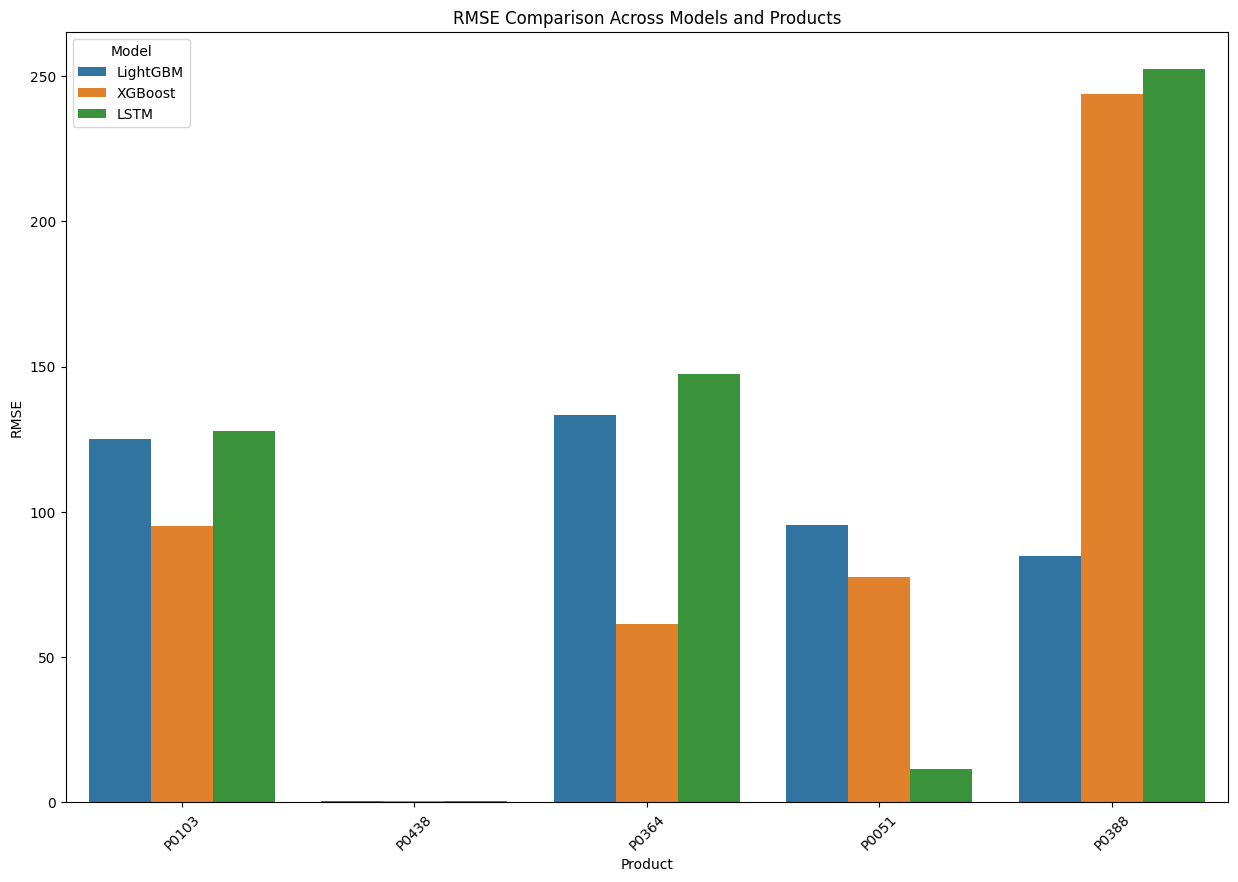

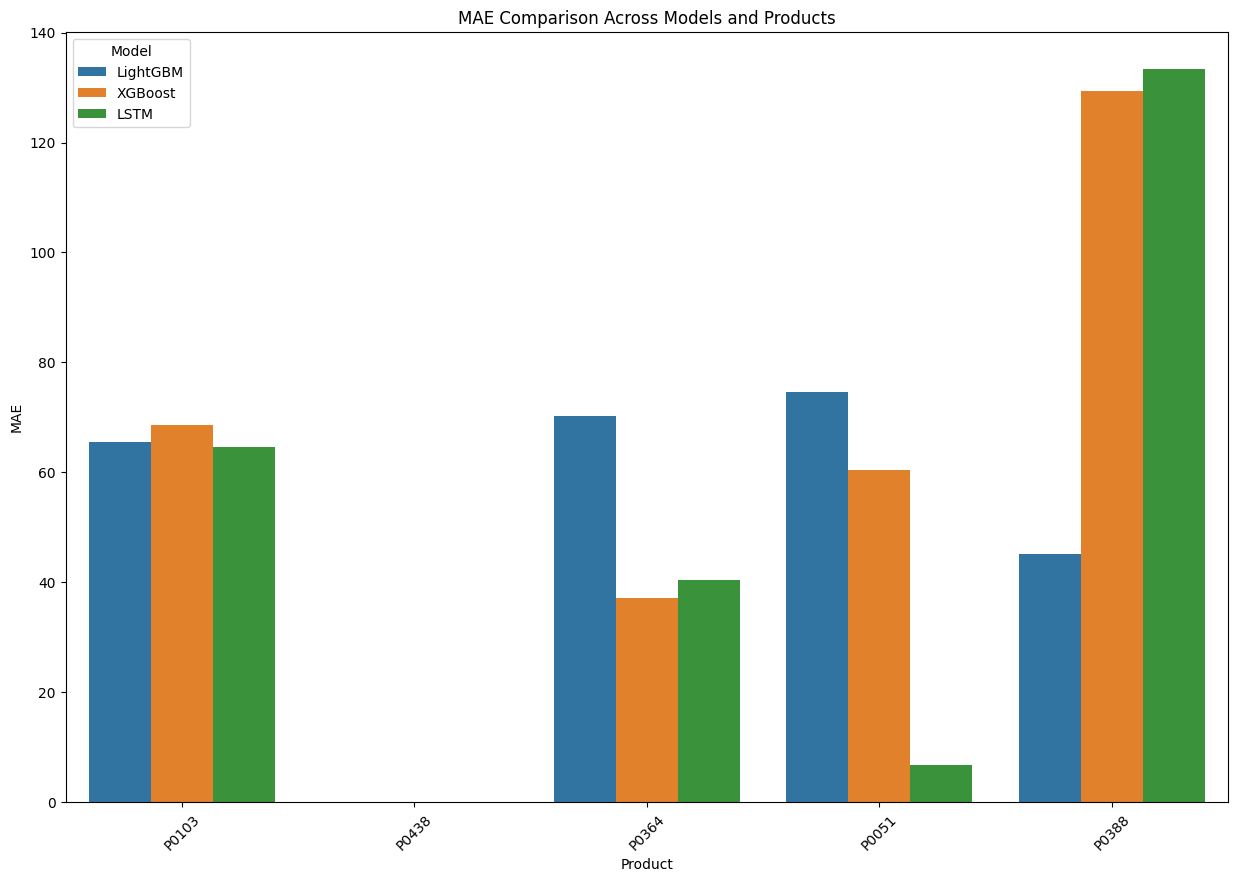

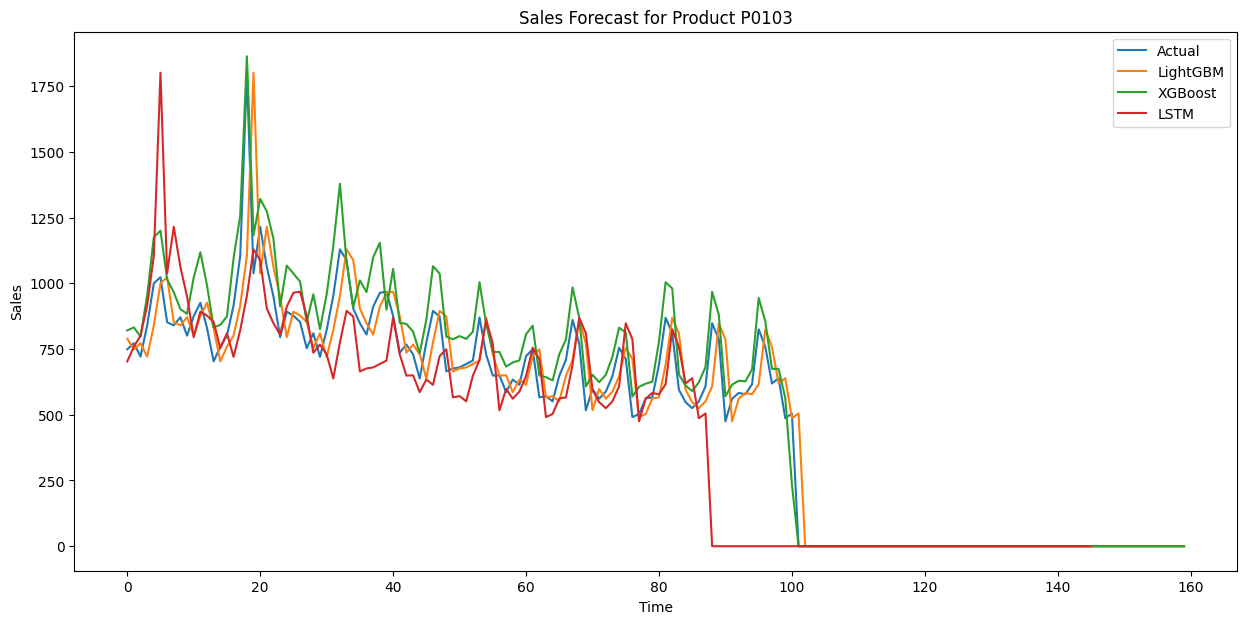

In [22]:
comparison_data = []
for product in top_products:
    comparison_data.append({
        'Product': product,
        'Model': 'LightGBM',
        'RMSE': lgbm_results[product]['rmse'],
        'MAE': lgbm_results[product]['mae'],
        'R2': lgbm_results[product]['r2']
    })
    comparison_data.append({
        'Product': product,
        'Model': 'XGBoost',
        'RMSE': xgb_results[product]['rmse'],
        'MAE': xgb_results[product]['mae'],
        'R2': xgb_results[product]['r2']
    })
    comparison_data.append({
        'Product': product,
        'Model': 'LSTM',
        'RMSE': lstm_results[product]['rmse'],
        'MAE': lstm_results[product]['mae'],
        'R2': lstm_results[product]['r2']
    })

comparison_df = pd.DataFrame(comparison_data)
print("Model Performance Comparison:")
print(comparison_df)

# Plotting the comparison
plt.figure(figsize=(15, 10))
sns.barplot(data=comparison_df, x='Product', y='RMSE', hue='Model')
plt.title('RMSE Comparison Across Models and Products')
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(15, 10))
sns.barplot(data=comparison_df, x='Product', y='MAE', hue='Model')
plt.title('MAE Comparison Across Models and Products')
plt.xticks(rotation=45)
plt.show()

# Plot predictions for a single product
product_to_plot = top_products[0]
plt.figure(figsize=(15, 7))
plt.plot(lgbm_results[product_to_plot]['y_test'].values, label='Actual')
plt.plot(lgbm_results[product_to_plot]['preds'], label='LightGBM')
plt.plot(xgb_results[product_to_plot]['preds'], label='XGBoost')
plt.plot(lstm_results[product_to_plot]['preds'], label='LSTM')
plt.title(f'Sales Forecast for Product {product_to_plot}')
plt.xlabel('Time')
plt.ylabel('Sales')
plt.legend()
plt.show()